# Advanced Machine Learnning Final Project

## Enviroment settings

In [1]:
!pip install torch transformers torch-geometric sentencepiece pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [2]:
!pip install tree-sitter==0.20.1 tree-sitter-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 10.1 MB/s eta 0:00:00
  Created wheel for tree-sitter: filename=tree_sitter-0.20.1-cp311-cp311-linux_x86_64.whl size=425843 sha256=6f55ecde9047b0cf3b1027f98491350eb30f1680a87d9a5327beb3fea90b1412
  Stored in directory: /root/.cache/pip/wheels/6c/be/3a/6841c52111041475b3c693b347ac03f305330cbf7fb1c6365d
Successfully built tree-sitter


In [3]:
!pip install torch_geometric

In [4]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import torch

import networkx as nx
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

from transformers import AutoTokenizer, AutoModel
from tree_sitter import Language, Parser, Node

from torch.nn import MultiheadAttention
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.utils import from_networkx

# Setting up for better visualization
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 10, 6
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

In [5]:
!git clone https://github.com/tree-sitter/tree-sitter-python.git

Cloning into 'tree-sitter-python'...
remote: Enumerating objects: 3520, done.
remote: Counting objects: 100% (1372/1372), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 3520 (delta 1260), reused 1174 (delta 1174), pack-reused 2148 (from 3)
Receiving objects: 100% (3520/3520), 22.54 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (2148/2148), done.


## Data preprocessing

---
!!! If you want to use already balanced dataset, go down and find another link!!!
-------



In [6]:
# !wget -O 'data.csv' -q 'https://www.dropbox.com/scl/fi/60mb3thmisg7qjtus6auu/final_dataset_with_validation_flags.csv?rlkey=p64jt028icxdsajlw3rob6649&st=db5op2tl&dl=0'

In [8]:
from google.colab import files
uploaded = files.upload()

Saving balanced_dataset.csv to balanced_dataset.csv


In [9]:
df = pd.read_csv('balanced_dataset.csv')

In [10]:
df.size

30368

In [11]:
df.sample(5)

,code,label,normalized_code,length,num_lines,avg_line_len,parenthesis_ratio,brace_ratio,ast_nodes,ast_if_count,ast_depth,ast_functions,ast_parse_success,token_count,keyword_count,preprocess_valid
204,"def max_sum_list(lists):\r\n return max(lists,...",1,"def max_sum_list(lists):\n return max(lists, k...",52.0,2.0,26.000000,0.076923,0.0,13,0,3,1,True,5,1,True
42,import re\r\ndef text_match_wordz_middle(text)...,1,import re\ndef text_match_wordz_middle(text):\...,203.0,7.0,29.000000,0.029557,0.0,24,1,3,1,True,17,2,True
1335,"def get(self, sid):\n """"""\n Cons...",0,"def get(self, sid):\n \n return ...",127.0,3.0,42.333333,0.031496,0.0,24,0,4,1,True,8,1,True
1157,"def bfx(value, msb, lsb):\n """"""! @brief Ext...",0,"def bfx(value, msb, lsb):\n \n mask = bi...",94.0,4.0,23.500000,0.085106,0.0,29,0,3,1,True,14,1,True
281,"def parallelogram_perimeter(b,h):\r\n perimet...",1,"def parallelogram_perimeter(b,h):\n perimeter...",72.0,3.0,24.000000,0.055556,0.0,20,0,3,1,True,5,1,True


In [12]:
df = df[df['ast_parse_success'] == True]
print(df[df['label'] == 1]['length'].describe(), end='\n\n')
print(df[df['label'] == 0]['length'].describe())

count     961.000000
mean      176.522373
std       126.814866
min        29.000000
25%        96.000000
50%       138.000000
75%       210.000000
max      1279.000000
Name: length, dtype: float64

count     913.000000
mean      188.044907
std       148.226072
min        56.000000
25%       101.000000
50%       144.000000
75%       219.000000
max      1234.000000
Name: length, dtype: float64


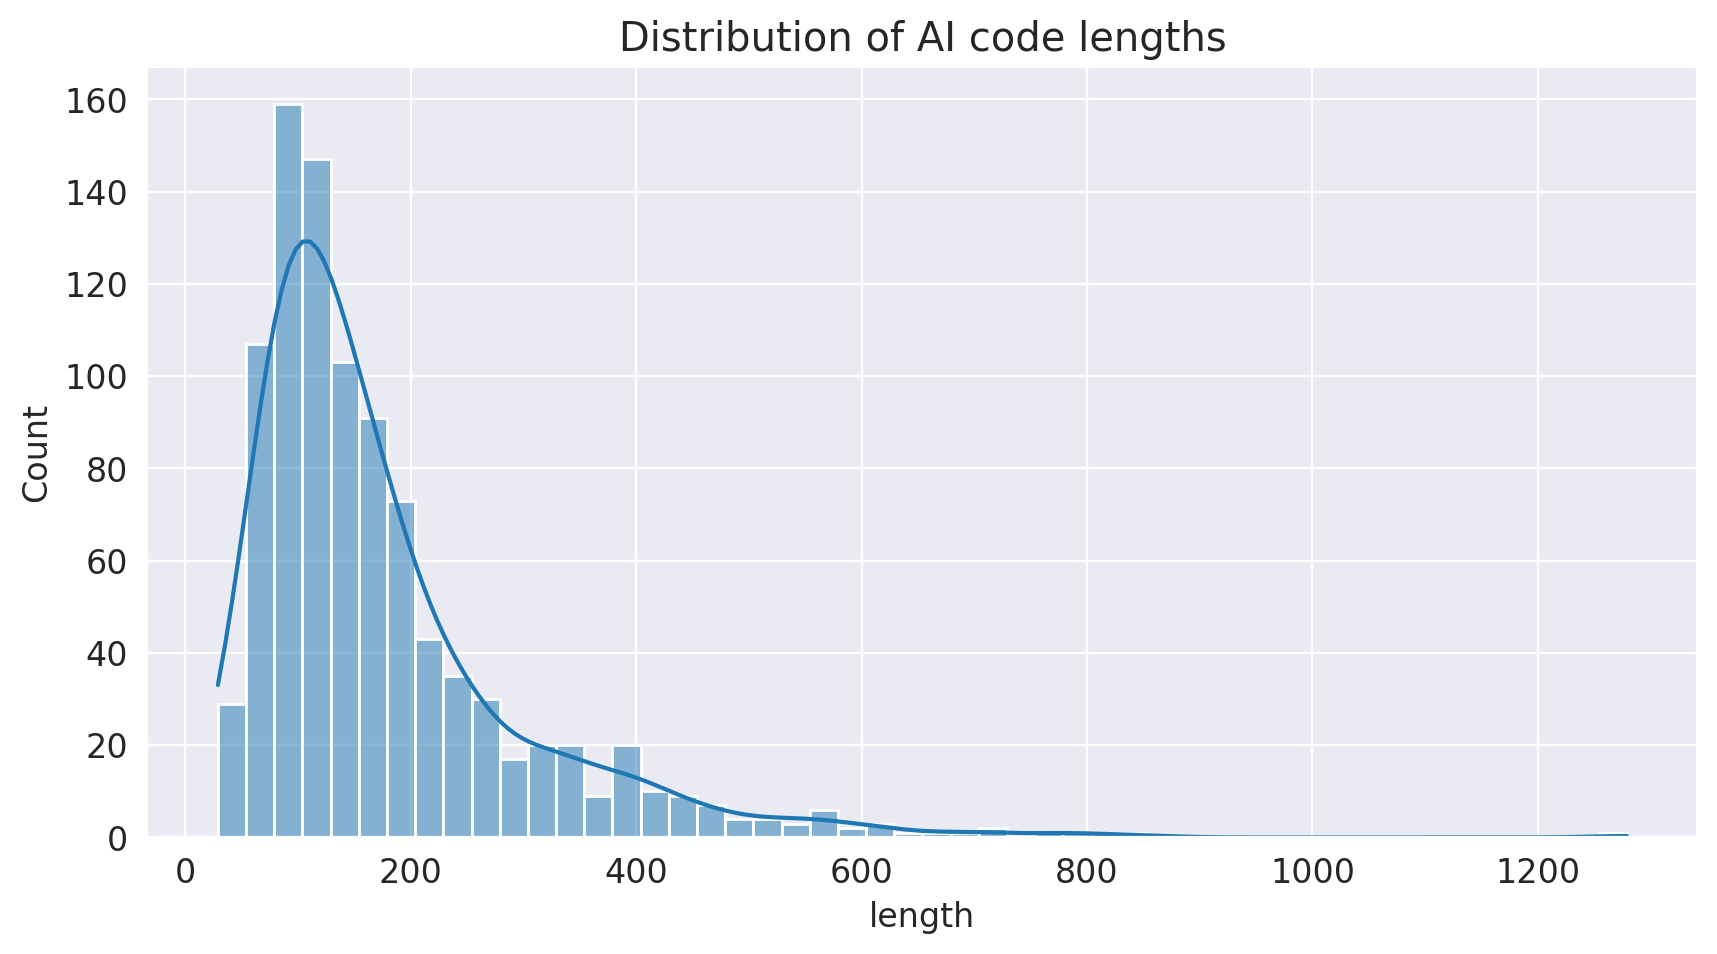

In [13]:
ai_code = df[df['label'] == 1]

plt.figure(figsize=(10, 5))
sns.histplot(ai_code['length'], bins=50, kde=True)
plt.title('Distribution of AI code lengths')
plt.show()

In [14]:
ai_code = df[df['label'] == 1]
human_code = df[df['label'] == 0]
n_bins = 20
ai_code['bin'] = pd.qcut(ai_code['length'], q=n_bins, duplicates='drop')

bin_stats = []
for bin_name, group in ai_code.groupby('bin'):
    bin_min = group['length'].min()
    bin_max = group['length'].max()
    bin_count = len(group)
    bin_stats.append({
        'bin': bin_name,
        'min': bin_min,
        'max': bin_max,
        'ai_count': bin_count
    })

human_samples = []
for stat in bin_stats:
    human_in_bin = human_code[
        (human_code['length'] >= stat['min']) &
        (human_code['length'] <= stat['max'])
    ]
    if len(human_in_bin) > 0:
        sample_size = min(stat['ai_count'], len(human_in_bin))
        human_samples.append(human_in_bin.sample(n=sample_size, random_state=42))

balanced_human = pd.concat(human_samples)
balanced_df = pd.concat([ai_code, balanced_human]).drop(columns=['bin'])

<ipython-input-14-c19f871e2404>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_code['bin'] = pd.qcut(ai_code['length'], q=n_bins, duplicates='drop')
<ipython-input-14-c19f871e2404>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_name, group in ai_code.groupby('bin'):


Distribution after balancing:
label
1    961
0    906
Name: count, dtype: int64
count     961.000000
mean      176.522373
std       126.814866
min        29.000000
25%        96.000000
50%       138.000000
75%       210.000000
max      1279.000000
Name: length, dtype: float64

count     906.000000
mean      187.947020
std       148.729535
min        56.000000
25%       101.000000
50%       143.500000
75%       219.000000
max      1234.000000
Name: length, dtype: float64


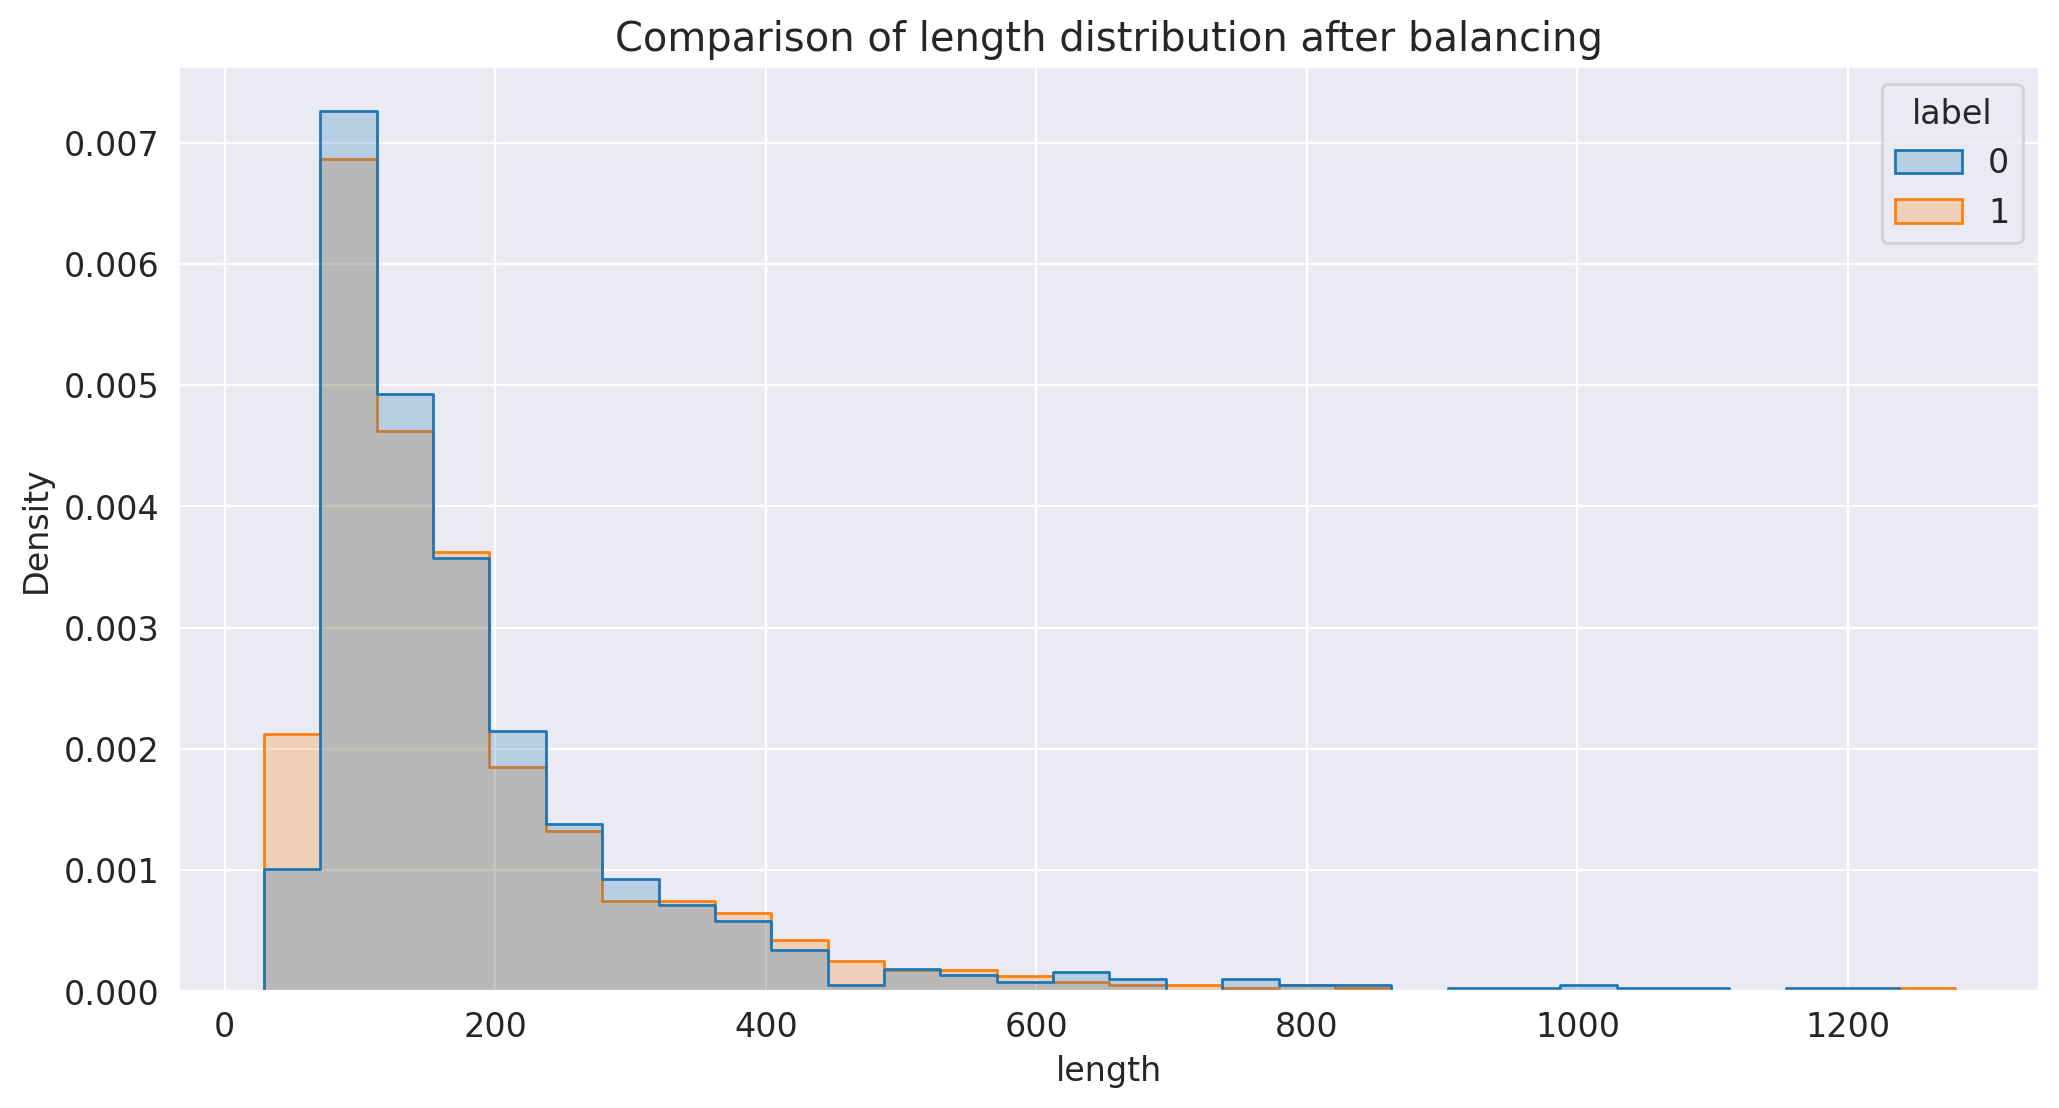

In [15]:
print("Distribution after balancing:")
print(balanced_df['label'].value_counts())
print(balanced_df[balanced_df['label'] == 1]['length'].describe(), end='\n\n')
print(balanced_df[balanced_df['label'] == 0]['length'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(
    data=balanced_df,
    x='length',
    hue='label',
    element='step',
    stat='density',
    common_norm=False,
    bins=30
)
plt.title('Comparison of length distribution after balancing')
plt.show()

In [16]:
print("Data gaps:")
print(balanced_df.isnull().sum())

print("\nАномалии в ast_nodes:")
print(balanced_df['ast_nodes'].describe())

print("\nАномалии в parenthesis_ratio:")
print(balanced_df['parenthesis_ratio'].describe())

Data gaps:
code                 0
label                0
normalized_code      0
length               0
num_lines            0
avg_line_len         0
parenthesis_ratio    0
brace_ratio          0
ast_nodes            0
ast_if_count         0
ast_depth            0
ast_functions        0
ast_parse_success    0
token_count          0
keyword_count        0
preprocess_valid     0
dtype: int64

Аномалии в ast_nodes:
count    1867.000000
mean       47.153723
std        38.185232
min        10.000000
25%        25.000000
50%        34.000000
75%        53.000000
max       365.000000
Name: ast_nodes, dtype: float64

Аномалии в parenthesis_ratio:
count    1867.000000
mean        0.052091
std         0.025941
min         0.005038
25%         0.033613
50%         0.047244
75%         0.065574
max         0.206897
Name: parenthesis_ratio, dtype: float64


In [17]:
df = balanced_df.copy()
df.to_csv('balanced_dataset.csv', index=False, encoding='utf-8')
df.columns

Index(['code', 'label', 'normalized_code', 'length', 'num_lines',
       'avg_line_len', 'parenthesis_ratio', 'brace_ratio', 'ast_nodes',
       'ast_if_count', 'ast_depth', 'ast_functions', 'ast_parse_success',
       'token_count', 'keyword_count', 'preprocess_valid'],
      dtype='object')

In [18]:
# Download already balanced dataset
# !wget -O 'balanced_dataset.csv' -q 'https://www.dropbox.com/scl/fi/o84fra6yzdgmimghnbbm0/balanced_dataset.csv?rlkey=u20uc1shec6b0cmx8sv457o95&st=myack85f&dl=0'
df = pd.read_csv('balanced_dataset.csv')

In [19]:
train_df, test_df = train_test_split(df, test_size=0.8, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42)

## Model Initialisation

 Preparing tokenizer for codebert

In [20]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [21]:
def tokenize_code(code):
    return tokenizer(
        code,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

In [22]:
# tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
# sample = tokenize_code("def hello(): print('world')")

Building AST and graphs

In [23]:
os.mkdir("build")

In [24]:
Language.build_library(
    "/content/build/my-languages.so",
    ["/content/tree-sitter-python"]
)

True

In [25]:
!ls ./build

my-languages.so


In [26]:
PYTHON_LANGUAGE = Language("/content/build/my-languages.so", "python")
parser = Parser()
parser.set_language(PYTHON_LANGUAGE)

In [27]:
def ast_to_graph(node: Node, graph=None, parent=None) -> nx.DiGraph:
    if graph is None:
        graph = nx.DiGraph()

    node_id = str(node.id)
    graph.add_node(node_id, label=node.type)

    if parent is not None:
        graph.add_edge(parent, node_id)

    for child in node.children:
        ast_to_graph(child, graph, node_id)

    return graph

### Model class

In [55]:
class CrossModalAttention(torch.nn.Module):
    def __init__(self, embed_dim=768, graph_feature_dim=128, num_heads=8):
        super().__init__()
        self.attention = torch.nn.MultiheadAttention(embed_dim, num_heads=num_heads)
        self.graph_proj = torch.nn.Sequential(
            torch.nn.Linear(graph_feature_dim, embed_dim),
            torch.nn.ReLU(),
        )
        self.dropout = torch.nn.Dropout(0.1)

    def forward(self, text_features, graph_features):
        # text_features: [seq_len, batch, 768]
        # graph_features: [batch, 128]
        graph_proj = self.graph_proj(graph_features).unsqueeze(0)  # [1, batch, 768]
        attn_output, _ = self.attention(
            text_features,
            graph_proj,
            graph_proj
        )
        return self.dropout(attn_output.mean(dim=0))  # [batch, 768]

In [65]:
class GNNBlock(torch.nn.Module):
    def __init__(self, num_node_types, hidden_dim=128, dropout=0.3): #0.3
        super().__init__()
        self.embed = torch.nn.Embedding(num_node_types + 1, hidden_dim, padding_idx=0)

        #self.conv1 = GATConv(hidden_dim, hidden_dim*2, heads=6, dropout = dropout)
        #self.conv2 = GATConv(hidden_dim * 2*6, hidden_dim*2, heads=4, dropout = dropout)
        #self.conv3 = GATConv(hidden_dim * 2*4, hidden_dim, heads=2, dropout = dropout)

        self.conv1 = GATConv(hidden_dim, hidden_dim, heads=4)
        self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=2)
        self.conv3 = GATConv(hidden_dim * 2, hidden_dim, heads=1)

    def forward(self, x, edge_index, batch):
        x = x.long().squeeze()

        assert torch.all(x >= 0), "Negative indexes!"
        assert torch.all(x < self.embed.num_embeddings), f"indexes exceed {self.embed.num_embeddings-1}"

        x = self.embed(x)
        x = F.leaky_relu(self.conv1(x, edge_index))
        x = F.leaky_relu(self.conv2(x, edge_index))
        x = F.leaky_relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)  # [batch_size, hidden_dim]

In [66]:
class CodeDetector(torch.nn.Module):
    def __init__(self, num_ast_types):
        super().__init__()
        self.bert = AutoModel.from_pretrained("microsoft/codebert-base")
        for param in self.bert.parameters():  # Freeze the first 6 layers
          param.requires_grad = False # ?????????????? todo
        self.gnn = GNNBlock(num_node_types=num_ast_types, hidden_dim=128)
        self.cross_attn = CrossModalAttention(embed_dim=768, graph_feature_dim=128)
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(768 + 128, 128),
            torch.nn.GELU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, graph_data):
        # BERT
        with torch.no_grad():
            bert_output = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state  # [batch, seq_len, 768]

        # GNN
        graph_features = self.gnn(
            x=graph_data.x,
            edge_index=graph_data.edge_index,
            batch=graph_data.batch
        )  # [batch, 128]

        # Cross Attention
        text_features = bert_output.permute(1, 0, 2)  # [seq_len, batch, 768]
        attended_text = self.cross_attn(text_features, graph_features)

        # Combining features
        combined = torch.cat([
            attended_text,
            graph_features
        ], dim=1)

        return self.classifier(combined)

In [67]:
class CodeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, parser, ast_types, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.parser = parser
        self.max_length = max_length
        self.node_type_mapping = {typ: i+1 for i, typ in enumerate(ast_types)}
        self.node_type_mapping["UNK"] = 0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        encoding = self.tokenizer(
            row['normalized_code'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        tree = self.parser.parse(bytes(row['normalized_code'], 'utf8'))
        graph = ast_to_graph(tree.root_node)

        node_ids = list(graph.nodes())
        node_id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}

        edges = []
        for src, dst in graph.edges():
            src_idx = node_id_to_idx[src]
            dst_idx = node_id_to_idx[dst]
            edges.append([src_idx, dst_idx])

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

        node_types = [graph.nodes[node_id]['label'] for node_id in node_ids]
        x = torch.tensor([
            self.node_type_mapping.get(typ, 0)
            for typ in node_types
        ], dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'graph': Data(x=x, edge_index=edge_index),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

## Training

In [68]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    tokenizer,
    device="cuda",
    epochs=10,
    early_stopping=3
):
    best_f1 = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        all_preds = []
        all_labels = []

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            graph_data = batch["graph"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, graph_data)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(labels.cpu().detach().numpy())

            progress_bar.set_postfix({'loss': loss.item()})

        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                graph_data = batch["graph"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids, attention_mask, graph_data)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_f1 = f1_score(all_labels, all_preds, average='binary')
        val_f1 = f1_score(val_labels, val_preds, average='binary')
        val_acc = accuracy_score(val_labels, val_preds)

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"\nEpoch {epoch+1}:")
        print(f"  Train Loss: {train_loss_avg:.4f} | Train F1: {train_f1:.4f}")
        print(f"  Val Loss: {val_loss_avg:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            no_improve = 0
            torch.save(model.state_dict(), "best_model.pth")
            print("  ↳ Saved new best model!")
        else:
            no_improve += 1
            if no_improve >= early_stopping:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load("best_model.pth"))
    return model, history

In [69]:
def get_num_ast_types(df, parser):
    ast_types = set()

    for code in df['code']:
        try:
            tree = parser.parse(bytes(code, "utf8"))
            def collect_types(node):
                ast_types.add(node.type)
                for child in node.children:
                    collect_types(child)
            collect_types(tree.root_node)
        except:
            continue

    print(f"Unique AST types = {len(ast_types)}")
    print(ast_types)
    return len(ast_types), ast_types

num_ast_types, ast_types = get_num_ast_types(df, parser)

Unique AST types = 164
{'true', 'with_item', 'or', 'string_content', 'return_statement', 'lambda', '%', 'global_statement', ':', 'list_splat', '<', 'try', '**', 'unary_operator', '*=', 'aliased_import', 'string_start', 'await', 'generator_expression', 'raise', 'async', ')', '{', 'finally', '*', '//=', 'call', '/', 'assert_statement', 'attribute', 'expression_statement', 'with_statement', 'else', 'comparison_operator', 'dictionary_comprehension', 'parameters', 'try_statement', 'dictionary', 'as', '>', '&', 'parenthesized_expression', 'assignment', 'tuple', 'float', '-', 'import', 'elif', 'slice', 'conditional_expression', 'identifier', 'escape_sequence', 'type_parameter', '/=', 'default_parameter', '<<', '.', 'string_end', 'if_statement', 'pair', 'assert', 'import_from_statement', '|', 'except', 'return', 'expression_list', 'keyword_argument', 'if', 'list_comprehension', 'import_statement', 'augmented_assignment', 'module', '-=', 'typed_default_parameter', 'list', 'generic_type', 'list_

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CodeDetector(num_ast_types=num_ast_types).to(device)#
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.gnn.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])
criterion = torch.nn.CrossEntropyLoss()

In [71]:
def custom_collate(batch):
    graph_data = [item['graph'] for item in batch]
    batch = {
        'input_ids': torch.stack([item['input_ids'] for item in batch]),
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'graph': Batch.from_data_list(graph_data),
        'label': torch.stack([item['label'] for item in batch])
    }
    return batch

In [72]:
train_dataset = CodeDataset(train_df, tokenizer, parser, ast_types)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=custom_collate
)

val_dataset = CodeDataset(val_df, tokenizer, parser, ast_types)
val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=custom_collate
)

In [83]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

#5 fold cross validation
num_folds = 5
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
    print(f"\n===== Fold {fold+1} =====")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_dataset = CodeDataset(train_df, tokenizer, parser, ast_types)
    val_dataset = CodeDataset(val_df, tokenizer, parser, ast_types)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate)


    model = CodeDetector(num_ast_types=num_ast_types).to(device)

    optimizer = torch.optim.AdamW([
        {'params': model.bert.parameters(), 'lr': 2e-5},
        {'params': model.gnn.parameters(), 'lr': 1e-3},
        {'params': model.classifier.parameters(), 'lr': 1e-3}
    ])
    criterion = torch.nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        tokenizer=tokenizer,
        device=device,
        epochs=15
    )

    # ========== each fold val ==========
    val_preds = []
    val_labels = []

    trained_model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            graph_data = batch["graph"].to(device)
            labels = batch["label"].to(device)

            outputs = trained_model(input_ids, attention_mask, graph_data)
            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # evaluation metrices
    acc = accuracy_score(val_labels, val_preds) * 100
    precision = precision_score(val_labels, val_preds, average='binary') * 100
    recall = recall_score(val_labels, val_preds, average='binary') * 100
    f1 = f1_score(val_labels, val_preds, average='binary') * 100
    try:
        auc = roc_auc_score(val_labels, val_preds) * 100
    except ValueError:
        auc = float('nan')

    print(f"Fold {fold+1} results:")
    print(f"  Acc: {acc:.2f}% | Precision: {precision:.2f}% | Recall: {recall:.2f}% | F1: {f1:.2f}% | AUC: {auc:.2f}%")

    fold_results.append({
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    })

# ========== 5-Fold Average Results ==========
accs = [r['acc'] for r in fold_results]
precisions = [r['precision'] for r in fold_results]
recalls = [r['recall'] for r in fold_results]
f1s = [r['f1'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]

print("\n===== 5-Fold Average Results =====")
print(f"  Acc: {sum(accs)/len(accs):.2f}%")
print(f"  Precision: {sum(precisions)/len(precisions):.2f}%")
print(f"  Recall: {sum(recalls)/len(recalls):.2f}%")
print(f"  F1: {sum(f1s)/len(f1s):.2f}%")
print(f"  AUC: {sum(aucs)/len(aucs):.2f}%")



===== Fold 1 =====


Epoch 1/15: 100%|██████████| 187/187 [00:23<00:00,  7.96it/s, loss=0.712]



Epoch 1:
  Train Loss: 0.3529 | Train F1: 0.8642
  Val Loss: 0.2233 | Val F1: 0.9134 | Val Acc: 0.9118
  ↳ Saved new best model!


Epoch 2/15: 100%|██████████| 187/187 [00:23<00:00,  7.99it/s, loss=0.435]



Epoch 2:
  Train Loss: 0.2105 | Train F1: 0.9248
  Val Loss: 0.2585 | Val F1: 0.9227 | Val Acc: 0.9198
  ↳ Saved new best model!


...


Epoch 5:
  Train Loss: 0.1910 | Train F1: 0.9428
  Val Loss: 0.1786 | Val F1: 0.9313 | Val Acc: 0.9276


Epoch 6/15: 100%|██████████| 187/187 [00:24<00:00,  7.52it/s, loss=0.987]



Epoch 6:
  Train Loss: 0.2051 | Train F1: 0.9375
  Val Loss: 0.1830 | Val F1: 0.9273 | Val Acc: 0.9223
Early stopping at epoch 6


<ipython-input-68-8d7e5ff81826>:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Fold 5 results:
  Acc: 93.03% | Precision: 92.78% | Recall: 93.75% | F1: 93.26% | AUC: 93.01%

===== 5-Fold Average Results =====
  Acc: 93.31%
  Precision: 91.35%
  Recall: 96.26%
  F1: 93.68%
  AUC: 93.22%


## Testing

In [84]:
def calculate_ai_percentage(model, test_df, tokenizer, parser, ast_types, device="cuda", batch_size=8):
    test_dataset = CodeDataset(test_df, tokenizer, parser, ast_types)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=custom_collate
    )

    model.eval()
    ai_percentages = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Processing test samples"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            graph_data = batch["graph"].to(device)

            logits = model(input_ids, attention_mask, graph_data)

            probs = F.softmax(logits, dim=1)
            ai_probs = probs[:, 1].cpu().numpy()
            ai_percentages.extend(ai_probs * 100)

    result_df = test_df.copy()
    result_df["ai_percent"] = ai_percentages
    return result_df

result_df = calculate_ai_percentage(
    model=trained_model,
    test_df=test_df,
    tokenizer=tokenizer,
    parser=parser,
    device=device,
    ast_types=ast_types
)

Processing test samples: 100%|██████████| 187/187 [00:21<00:00,  8.53it/s]


In [ ]:
result_df[["code", "label", "ai_percent"]].head(10)

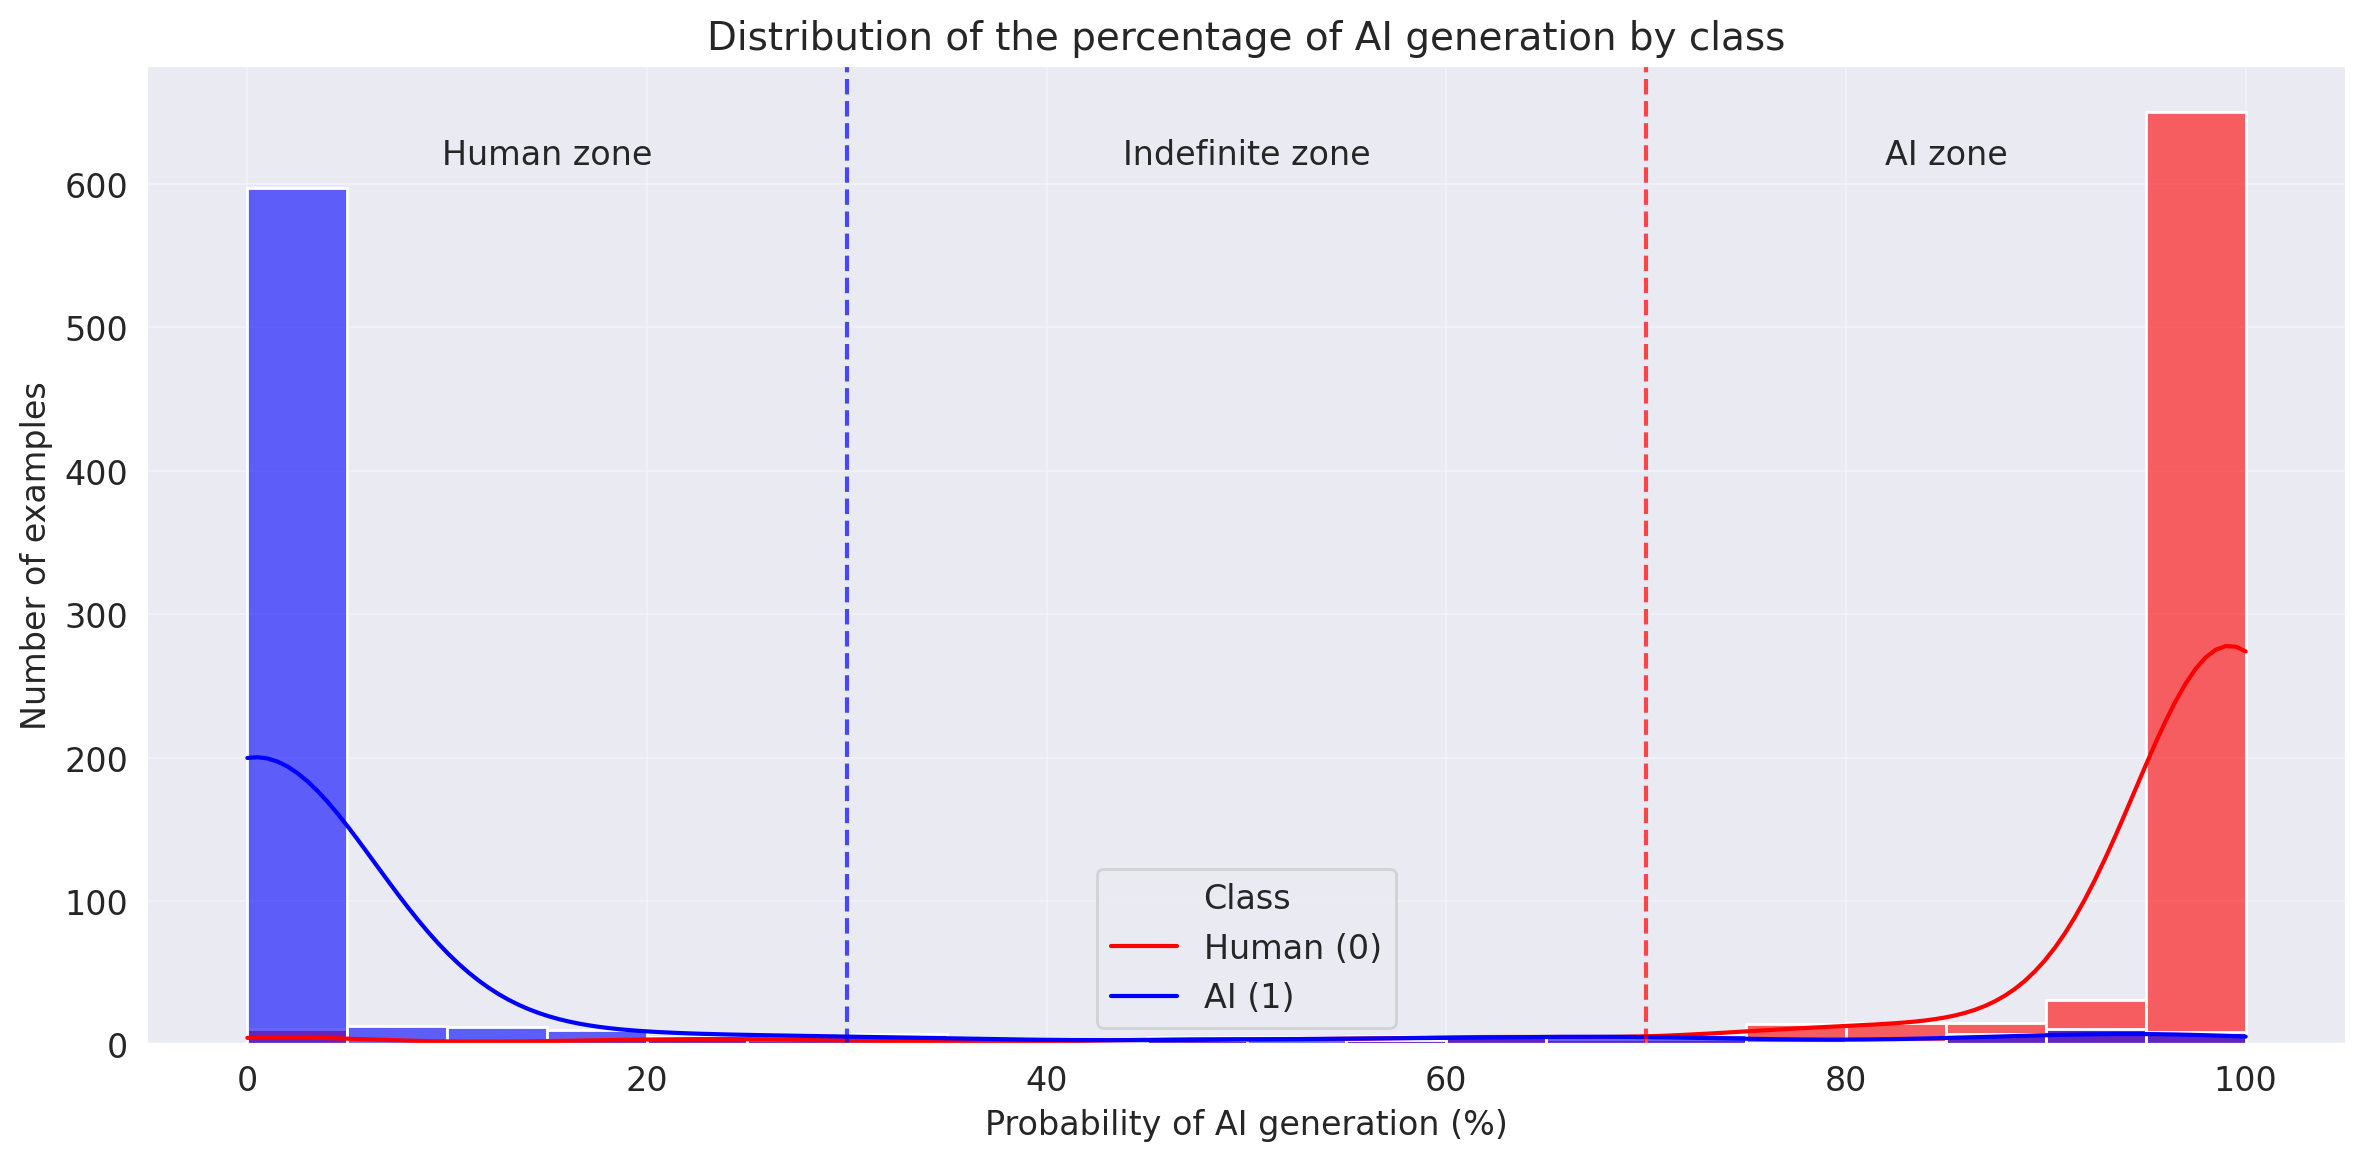


Average percentage of AI for classes:
Human code (0): 8.2%
AI-generated code (1): 93.6%
Diff: 85.4%


In [86]:
def plot_ai_distribution(result_df):
    plt.figure(figsize=(12, 6))

    ax = sns.histplot(
        data=result_df,
        x='ai_percent',
        hue='label',
        bins=20,
        kde=True,
        palette={0: 'blue', 1: 'red'},
        alpha=0.6,
        # edgecolor='none'
    )


    plt.title('Distribution of the percentage of AI generation by class', fontsize=14)
    plt.xlabel('Probability of AI generation (%)', fontsize=12)
    plt.ylabel('Number of examples', fontsize=12)
    plt.legend(title='Class', labels=['Human (0)', 'AI (1)'])

    plt.axvline(30, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(70, color='red', linestyle='--', alpha=0.7)
    plt.text(15, plt.ylim()[1]*0.9, 'Human zone', ha='center')
    plt.text(50, plt.ylim()[1]*0.9, 'Indefinite zone', ha='center')
    plt.text(85, plt.ylim()[1]*0.9, 'AI zone', ha='center')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def print_class_stats(result_df):
    human_mean = result_df[result_df['label'] == 0]['ai_percent'].mean()
    ai_mean = result_df[result_df['label'] == 1]['ai_percent'].mean()

    print(f"\nAverage percentage of AI for classes:")
    print(f"Human code (0): {human_mean:.1f}%")
    print(f"AI-generated code (1): {ai_mean:.1f}%")
    print(f"Diff: {abs(human_mean - ai_mean):.1f}%")

plot_ai_distribution(result_df)
print_class_stats(result_df)

## check tests

In [87]:
test_batch = next(iter(train_loader))
print(f"Input IDs shape: {test_batch['input_ids'].shape}")
print(f"Graph nodes: {test_batch['graph'].x.shape}")
print(f"Graph edges: {test_batch['graph'].edge_index.shape}")

Input IDs shape: torch.Size([8, 256])
Graph nodes: torch.Size([658])
Graph edges: torch.Size([2, 650])


In [88]:
def test_gnn():
    num_node_types = 164
    batch_size = 2
    hidden_dim = 128

    test_data = [
        {
            'x': torch.randint(0, num_node_types-1, (5,)),
            'edge_index': torch.tensor([[0,1,2,3], [1,2,3,4]], dtype=torch.long),
            'batch': torch.tensor([0,0,0,1,1])
        },
        {
            'x': torch.randint(0, num_node_types-1, (3,)),
            'edge_index': torch.tensor([[0,1], [1,2]], dtype=torch.long),
            'batch': torch.tensor([0,0,1])
        }
    ]

    gnn = GNNBlock(num_node_types=num_node_types, hidden_dim=hidden_dim)

    print("\nTesting on CPU:")
    for i, data in enumerate(test_data):
        try:
            out = gnn(data['x'], data['edge_index'], data['batch'])
            assert out.shape == (batch_size if i==0 else 2, hidden_dim)
            print(f"Test {i+1} CPU: OK [Output shape: {out.shape}]")
        except Exception as e:
            print(f"Test {i+1} CPU: FAILED - {str(e)}")

    if torch.cuda.is_available():
        print("\nTesting on GPU:")
        gnn = gnn.to('cuda')
        for i, data in enumerate(test_data):
            try:
                x = data['x'].to('cuda')
                edge_index = data['edge_index'].to('cuda')
                batch = data['batch'].to('cuda')

                out = gnn(x, edge_index, batch)
                assert out.shape == (batch_size if i==0 else 2, hidden_dim)
                print(f"Test {i+1} GPU: OK [Output shape: {out.shape}]")
            except Exception as e:
                print(f"Test {i+1} GPU: FAILED - {str(e)}")

test_gnn()


Testing on CPU:
Test 1 CPU: OK [Output shape: torch.Size([2, 128])]
Test 2 CPU: OK [Output shape: torch.Size([2, 128])]

Testing on GPU:
Test 1 GPU: OK [Output shape: torch.Size([2, 128])]
Test 2 GPU: OK [Output shape: torch.Size([2, 128])]


In [89]:
def check_embeddings(loader, model):
    model.eval()
    with torch.no_grad():
        for batch in loader:
            graph = batch['graph'].to(device)
            try:
                out = model.gnn(graph.x, graph.edge_index, graph.batch)
                print("Batch OK")
            except Exception as e:
                print("Error:", str(e))
                print("Problematic node indices:", graph.x.min(), graph.x.max())
                break
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

check_embeddings(train_loader, model)

Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
Batch OK
B

In [90]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

def debug_data_loading(loader):
    for i, batch in enumerate(loader):
        print(f"\nBatch {i+1} debug:")
        print("Input IDs device:", batch['input_ids'].device)
        print("Graph data keys:", batch['graph'].keys())

        x = batch['graph'].x
        print("Node indices shape:", x.shape)
        print("Min index:", x.min().item())
        print("Max index:", x.max().item())

        edge_index = batch['graph'].edge_index
        print("Edge index shape:", edge_index.shape)
        print("Min edge idx:", edge_index.min().item())
        print("Max edge idx:", edge_index.max().item())

        num_nodes = x.size(0)
        if (edge_index >= num_nodes).any():
            print("ERROR: Edge index exceeds number of nodes!")
            print("Problematic edges:",
                  torch.where(edge_index >= num_nodes))
            return

        if (x < 0).any() or (x >= model.gnn.embed.num_embeddings).any():
            print("ERROR: Invalid node indices!")
            print("Valid range: 0 -", model.gnn.embed.num_embeddings-1)
            print("Actual range:", x.min().item(), "-", x.max().item())
            return

        print("Data validation passed!")

debug_data_loading(train_loader)


Batch 1 debug:
Input IDs device: cpu
Graph data keys: ['batch', 'edge_index', 'x', 'ptr']
Node indices shape: torch.Size([372])
Min index: 1
Max index: 156
Edge index shape: torch.Size([2, 364])
Min edge idx: 0
Max edge idx: 371
Data validation passed!

Batch 2 debug:
Input IDs device: cpu
Graph data keys: ['batch', 'edge_index', 'x', 'ptr']
Node indices shape: torch.Size([692])
Min index: 3
Max index: 163
Edge index shape: torch.Size([2, 684])
Min edge idx: 0
Max edge idx: 691
Data validation passed!

Batch 3 debug:
Input IDs device: cpu
Graph data keys: ['batch', 'edge_index', 'x', 'ptr']
Node indices shape: torch.Size([885])
Min index: 2
Max index: 163
Edge index shape: torch.Size([2, 877])
Min edge idx: 0
Max edge idx: 884
Data validation passed!

Batch 4 debug:
Input IDs device: cpu
Graph data keys: ['batch', 'edge_index', 'x', 'ptr']
Node indices shape: torch.Size([665])
Min index: 3
Max index: 162
Edge index shape: torch.Size([2, 657])
Min edge idx: 0
Max edge idx: 664
Data val